<a href="https://colab.research.google.com/github/jonaslucambafernando-hash/FinalProject_SQL_Python_DURHAM_2026/blob/main/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# SECTION 1: IMPORTS AND PYTHON ENVIRONMENT
# =====================================================

# Data manipulation
import pandas as pd

# Numerical calculations
import numpy as np

# Graphs and visualisation
import matplotlib.pyplot as plt

# Dates and time
import datetime

# in industry we use GCP (Google Cloud Platform)
import pandas_datareader.data as web

# Check that the imports worked
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# =====================================================
# SECTION 2: PYTHON VARIABLES AND DATA TYPES
# =====================================================

# String (text)
stock_ticker = "GFTC"

# Float (decimal number)
market_price = 150.25

# Integer (whole number)
shares_traded = 1000

# Boolean (True or False)
is_volatile = True

# Display the variables
print(f"Asset: {stock_ticker}")
print(f"Market Price: {market_price}")
print(f"Shares Traded: {shares_traded}")
print(f"Is Volatile: {is_volatile}")

Asset: GFTC
Market Price: 150.25
Shares Traded: 1000
Is Volatile: True


In [3]:
# =====================================================
# SECTION 3: PYTHON DICTIONARIES
# =====================================================

# Create a dictionary
asset = {
    "Asset_ID": "A1",
    "Sector": "Technology",
    "Return": 0.05,
    "Volatility": 0.12
}

# Display the dictionary
print(asset)

# Access individual values
print("Asset ID:", asset["Asset_ID"])
print("Sector:", asset["Sector"])
print("Return:", asset["Return"])

{'Asset_ID': 'A1', 'Sector': 'Technology', 'Return': 0.05, 'Volatility': 0.12}
Asset ID: A1
Sector: Technology
Return: 0.05


In [5]:
# =====================================================
# SECTION 4: CREATING A PANDAS DATAFRAME
# =====================================================

# Create the dictionary
data = {
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'],
    'Sector': ['Tech', 'Fin', 'Tech', 'Energy', 'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'],
    'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0],
    'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10],
    'Description': [
        'High growth tech',
        'Stable financial',
        'Volatile software',
        'Oil production',
        'Unknown bank',
        'AI startup',
        'Solar energy',
        'E-commerce',
        'Store A',
        'Store B'
    ]
}

# Convert the dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

,Asset_ID,Sector,Returns,Volatility,Description
0,A1,Tech,0.05,0.12,High growth tech
1,A2,Fin,0.02,0.08,Stable financial
2,A3,Tech,-0.01,0.15,Volatile software
3,A4,Energy,0.08,0.20,Oil production
4,A5,Fin,NaN,0.10,Unknown bank
5,A6,Tech,0.04,0.11,AI startup
6,A7,Energy,0.15,0.25,Solar energy
7,A8,Tech,-0.02,0.13,E-commerce
8,A9,Retail,0.01,0.09,Store A
9,A10,Retail,5.00,0.10,Store B


In [6]:
# =====================================================
# SECTION 5: HANDLING MISSING VALUES
# =====================================================

# Create a copy of the original DataFrame
df_fin = df.copy()

# Replace missing values in the Returns column
# with the average (mean) of the observed returns
df_fin['Returns_Imp'] = df_fin['Returns'].fillna(
    df_fin['Returns'].mean()
)

# Check whether any missing values remain
print(
    f"Missing values after imputation: "
    f"{df_fin['Returns_Imp'].isna().sum()}"
)

# Display the relevant columns
df_fin[['Asset_ID', 'Returns', 'Returns_Imp']]

Missing values after imputation: 0


,Asset_ID,Returns,Returns_Imp
0,A1,0.05,0.050000
1,A2,0.02,0.020000
2,A3,-0.01,-0.010000
3,A4,0.08,0.080000
4,A5,NaN,0.591111
5,A6,0.04,0.040000
6,A7,0.15,0.150000
7,A8,-0.02,-0.020000
8,A9,0.01,0.010000
9,A10,5.00,5.000000


In [7]:
# =====================================================
# SECTION 6: OUTLIERS AND WINSORISATION
# =====================================================

# Import the winsorize function
from scipy.stats.mstats import winsorize

# Create a new column where extreme values are capped
df_fin['Returns_Clean'] = winsorize(
    df_fin['Returns_Imp'],
    limits=(0.05, 0.05)
)

# Display the original, imputed, and cleaned returns
df_fin[['Asset_ID', 'Returns', 'Returns_Imp', 'Returns_Clean']]

,Asset_ID,Returns,Returns_Imp,Returns_Clean
0,A1,0.05,0.050000,0.050000
1,A2,0.02,0.020000,0.020000
2,A3,-0.01,-0.010000,-0.010000
3,A4,0.08,0.080000,0.080000
4,A5,NaN,0.591111,0.591111
5,A6,0.04,0.040000,0.040000
6,A7,0.15,0.150000,0.150000
7,A8,-0.02,-0.020000,-0.020000
8,A9,0.01,0.010000,0.010000
9,A10,5.00,5.000000,5.000000


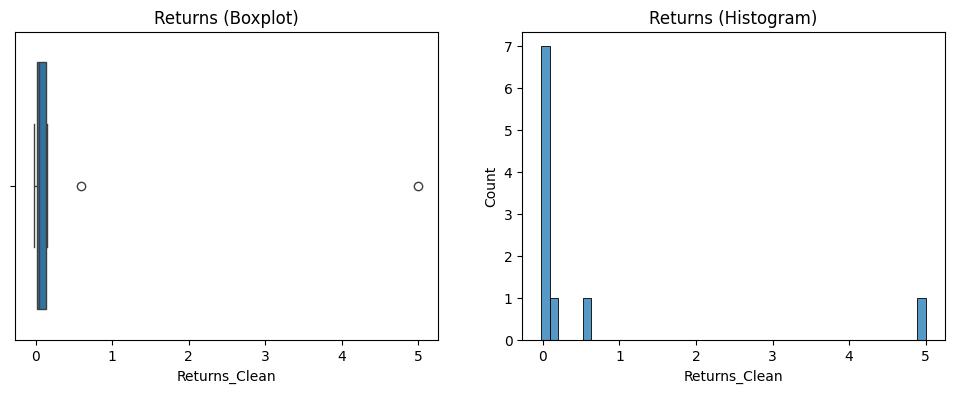

In [8]:
# =====================================================
# SECTION 7: DATA VISUALISATION
# =====================================================

# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 plots side by side
plt.figure(figsize=(12, 4))

# First plot: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df_fin['Returns_Clean'])
plt.title("Returns (Boxplot)")

# Second plot: Histogram
plt.subplot(1, 2, 2)
sns.histplot(df_fin['Returns_Clean'])
plt.title("Returns (Histogram)")

# Display the plots
plt.show()

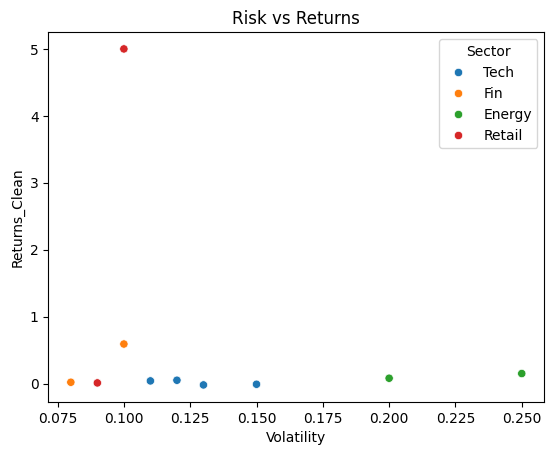

In [9]:
# =====================================================
# SECTION 8: SCATTERPLOT - RISK VS RETURNS
# =====================================================

# Create a scatterplot
sns.scatterplot(
    data=df_fin,
    x='Volatility',
    y='Returns_Clean',
    hue='Sector'
)

# Add a title
plt.title("Risk vs Returns")

# Display the graph
plt.show()

In [10]:
# =====================================================
# SECTION 9: OLS REGRESSION WITH STATSMODELS
# =====================================================

# Install statsmodels if needed
!pip install statsmodels

# Import the statsmodels library
import statsmodels.api as sm

# Define the independent variable
X = df_fin['Volatility']

# Add a constant/intercept to the model
X = sm.add_constant(X)

# Define the dependent variable
y = df_fin['Returns_Clean']

# Estimate the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Display the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                    0.4006
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.544
Time:                        19:59:44   Log-Likelihood:                -17.862
No. Observations:                  10   AIC:                             39.72
Df Residuals:                       8   BIC:                             40.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4336      1.426      1.006      0.3

In [11]:
# =====================================================
# SECTION 10: K-MEANS CLUSTERING
# =====================================================

# Import the KMeans algorithm
from sklearn.cluster import KMeans

# Estimate the clustering model
kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
).fit(df_fin[['Returns_Clean', 'Volatility']])

# Store the cluster assignment for each asset
df_fin['Risk_Group'] = kmeans.labels_

# Display the results
print("Assets assigned to risk clusters.")
df_fin[['Asset_ID', 'Returns_Clean', 'Volatility', 'Risk_Group']]

Assets assigned to risk clusters.


,Asset_ID,Returns_Clean,Volatility,Risk_Group
0,A1,0.050000,0.12,0
1,A2,0.020000,0.08,0
2,A3,-0.010000,0.15,0
3,A4,0.080000,0.20,0
4,A5,0.591111,0.10,2
5,A6,0.040000,0.11,0
6,A7,0.150000,0.25,0
7,A8,-0.020000,0.13,0
8,A9,0.010000,0.09,0
9,A10,5.000000,0.10,1


In [12]:
# =====================================================
# SECTION 11: DOWNLOADING FINANCIAL DATA
# =====================================================

# Import the Yahoo Finance library
import yfinance as yf

# Define the ticker symbol for the S&P 500 index
SP500_ticker = "^GSPC"

# Download historical data
sp500_data = yf.download(
    SP500_ticker,
    start="2020-01-01",
    end="2023-01-01"
)

# Display the first 5 rows
sp500_data.head()

/tmp/ipykernel_15674/2073717375.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


In [13]:
# =====================================================
# SECTION 12: CREATING AN SQLITE DATABASE

# Note: SQL is used to retrieve, filter, join and aggregate subsets of data from
# a database before they are analysed in Python and R.
# =====================================================

# Import the SQLite package
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Save the DataFrame into the SQL database
df_fin.to_sql(
    'finance_table',
    conn,
    index=False,
    if_exists='replace'
)

print("Database created successfully.")
print("Table 'finance_table' loaded into SQLite.")

Database created successfully.
Table 'finance_table' loaded into SQLite.


In [14]:
# -----------------------------------------------------
# CELL 13 - SQL Queries with pandasql
# -----------------------------------------------------

# Install pandasql (only once per Colab session)
!pip install pandasql

# Import the package
from pandasql import sqldf

# Create a helper function
# This allows us to execute SQL queries on Pandas DataFrames
pysqldf = lambda q: sqldf(q, globals())

# -----------------------------------------------------
# First SQL Query
# -----------------------------------------------------

query_ps = """
SELECT Asset_ID,
       Sector,
       Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""

# Execute the SQL query and display the result
result = pysqldf(query_ps)
print(result)

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=59cd23c9bea6cb0a3e7165c5fc37e9af5e5d2c83f4f751b10e4207c17927a21e
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
  Asset_ID Sector  Returns_Clean
0       A1   Tech           0.05
1       A3   Tech          -0.01
2       A6   Tech           0.04
3       A8   Tech          -0.02


In [15]:
# -----------------------------------------------------
# CELL 14 - Creating a Second Table
# -----------------------------------------------------

import pandas as pd

# Create a second DataFrame containing additional information
asset_metadata = pd.DataFrame({
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'Full_Name': [
        'Apple Inc',
        'JP Morgan',
        'Microsoft',
        'Exxon Mobil',
        'Goldman Sachs'
    ],
    'Country': [
        'USA',
        'USA',
        'USA',
        'USA',
        'USA'
    ]
})

# Display the new table
print(asset_metadata)

  Asset_ID      Full_Name Country
0       A1      Apple Inc     USA
1       A2      JP Morgan     USA
2       A3      Microsoft     USA
3       A4    Exxon Mobil     USA
4       A5  Goldman Sachs     USA


In [16]:
# -----------------------------------------------------
# CELL 15 - SQL JOIN
# -----------------------------------------------------

query_join = """
SELECT
    df_fin.Asset_ID,
    asset_metadata.Full_Name,
    df_fin.Sector,
    df_fin.Returns_Clean,
    asset_metadata.Country
FROM df_fin
INNER JOIN asset_metadata
ON df_fin.Asset_ID = asset_metadata.Asset_ID
"""

# Execute the SQL query
result_join = pysqldf(query_join)

# Display the result
print(result_join)

  Asset_ID      Full_Name  Sector  Returns_Clean Country
0       A1      Apple Inc    Tech       0.050000     USA
1       A2      JP Morgan     Fin       0.020000     USA
2       A3      Microsoft    Tech      -0.010000     USA
3       A4    Exxon Mobil  Energy       0.080000     USA
4       A5  Goldman Sachs     Fin       0.591111     USA


In [17]:
# -----------------------------------------------------
# SQL GROUP BY: average volatility by sector
# -----------------------------------------------------

import sqlite3

conn = sqlite3.connect(':memory:')

df_fin.to_sql('finance_table', conn, index=False, if_exists='replace')

query = """
SELECT Sector,
       AVG(Volatility) AS Avg_Vol
FROM finance_table
GROUP BY Sector
"""

sql_results = pd.read_sql_query(query, conn)

display(sql_results)

,Sector,Avg_Vol
0,Energy,0.2250
1,Fin,0.0900
2,Retail,0.0950
3,Tech,0.1275


In [18]:
# -----------------------------------------------------
# pandasql: use SQL directly on a Pandas DataFrame
# -----------------------------------------------------

!pip install pandasql

from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())

query_ps = """
SELECT Asset_ID,
       Sector,
       Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""

print(pysqldf(query_ps))

  Asset_ID Sector  Returns_Clean
0       A1   Tech           0.05
1       A3   Tech          -0.01
2       A6   Tech           0.04
3       A8   Tech          -0.02


In [19]:
# -----------------------------------------------------
# INNER JOIN: combine two tables using Asset_ID
# -----------------------------------------------------

asset_metadata = pd.DataFrame({
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft', 'Exxon Mobil', 'Goldman Sachs'],
    'Country': ['USA', 'USA', 'USA', 'USA', 'USA']
})

query_join = """
SELECT
    df_fin.Asset_ID,
    asset_metadata.Full_Name,
    df_fin.Sector,
    df_fin.Returns_Clean,
    asset_metadata.Country
FROM df_fin
INNER JOIN asset_metadata
ON df_fin.Asset_ID = asset_metadata.Asset_ID
"""

join_results = pysqldf(query_join)

display(join_results)

,Asset_ID,Full_Name,Sector,Returns_Clean,Country
0,A1,Apple Inc,Tech,0.050000,USA
1,A2,JP Morgan,Fin,0.020000,USA
2,A3,Microsoft,Tech,-0.010000,USA
3,A4,Exxon Mobil,Energy,0.080000,USA
4,A5,Goldman Sachs,Fin,0.591111,USA


In [20]:
# -----------------------------------------------------
# FRED data: retrieve GDP and query it with SQL
# -----------------------------------------------------

import datetime
import pandas_datareader.data as web

start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime(2023, 1, 1)

fred_data = web.DataReader('GDP', 'fred', start_date, end_date)

print("FRED GDP data retrieved:")
display(fred_data.head())

FRED GDP data retrieved:


,GDP
DATE,
2000-01-01,10002.179
2000-04-01,10247.720
2000-07-01,10318.165
2000-10-01,10435.744
2001-01-01,10470.231


In [21]:
# -----------------------------------------------------
# Query FRED data with SQL
# -----------------------------------------------------

fred_df_sql = fred_data.reset_index()

query_fred = """
SELECT DATE,
       GDP
FROM fred_df_sql
WHERE GDP > 25000
ORDER BY DATE DESC
"""

gdp_high_results = pysqldf(query_fred)

print("--- High GDP Periods (from FRED) ---")
display(gdp_high_results.head())

--- High GDP Periods (from FRED) ---


,DATE,GDP
0,2023-01-01 00:00:00.000000,27216.445
1,2022-10-01 00:00:00.000000,26770.514
2,2022-07-01 00:00:00.000000,26336.304
3,2022-04-01 00:00:00.000000,25861.292
4,2022-01-01 00:00:00.000000,25250.347
